In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, stats
import itertools

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.edgecolor': 'white',

    # Text colors to black
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.labelcolor': 'black',

    # Tick labels
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    # Axis spines, ticks, and edges to black
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
})
plt.rc('text', usetex=False)
plt.rc('mathtext', fontset='stix')
figsize = (7, 5)
fontSize = 13

In [2]:
# --- Fecal calprotectin ELISA (Supplementary Figure S22, Table S8) ---------
# The clinical reference marker
#  two-sided exact Mann-Whitney U.
FILE = Path("../raw data/calprotectin/calprotectin_data.csv")

df = pd.read_csv(FILE)
df

,mouse,group,calprotectin_pg_per_ml
0,1,DSS,283.50000
1,2,DSS,1163.00000
2,3,DSS,4178.50000
3,4,DSS,4748.00000
4,5,DSS,318.00000
5,6,Healthy,388.66670
6,7,Healthy,33.66667
7,8,Healthy,47.33333
8,9,Healthy,81.66667
9,10,Healthy,69.16667


In [3]:
dss = df.loc[df['group'] == 'DSS', 'calprotectin_pg_per_ml'].values
hea = df.loc[df['group'] == 'Healthy', 'calprotectin_pg_per_ml'].values

u, p = stats.mannwhitneyu(dss, hea, alternative='two-sided', method='exact')
print("n = %d vs %d" % (len(dss), len(hea)))
print("median DSS     = %.1f pg/mL" % np.median(dss))
print("median Healthy = %.1f pg/mL" % np.median(hea))
print("fold-change in medians = %.1f" % (np.median(dss) / np.median(hea)))
print("two-sided exact Mann-Whitney U = %.1f, p = %.4f" % (u, p))

n = 5 vs 5
median DSS     = 1163.0 pg/mL
median Healthy = 69.2 pg/mL
fold-change in medians = 16.8
two-sided exact Mann-Whitney U = 23.0, p = 0.0317


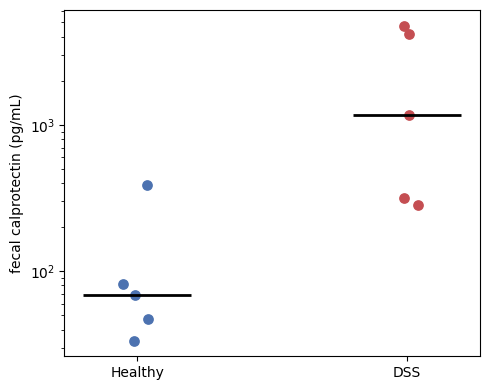

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
for i, (name, v) in enumerate([('Healthy', hea), ('DSS', dss)]):
    ax.scatter(np.full(len(v), i) + np.random.uniform(-.06, .06, len(v)), v,
               s=45, color=['#4C72B0', '#C44E52'][i], zorder=3)
    ax.hlines(np.median(v), i - .2, i + .2, color='black', lw=2, zorder=4)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Healthy', 'DSS'])
ax.set_ylabel('fecal calprotectin (pg/mL)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()